<a href="https://colab.research.google.com/github/Vaishakh252/Walmart-case-study/blob/main/Yulu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

collab link: https://colab.research.google.com/drive/11B3tvSxJbiWz0r6W9b1ge36LQBj3dGu0?usp=sharing

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import binom

import scipy.stats as stats

from scipy.stats import norm

from statsmodels.stats import power

import random

from statsmodels.stats import weightstats as stests

import statsmodels.api as sm

import math

from scipy.stats import ttest_1samp

from scipy.stats import ttest_ind

from scipy.stats import ttest_rel

from scipy.stats import f_oneway

from scipy.stats import levene

from scipy.stats import chi2_contingency

In [ ]:
df=pd.read_csv('bike_sharing.csv')
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


#1. Define the Problem Statement, Import the required Libraries and perform Exploratory Data Analysis.

##a. Examine dataset structure, characteristics, and statistical summary.

In [ ]:
df.dtypes

datetime       object
season          int64
holiday         int64
workingday      int64
weather         int64
temp          float64
atemp         float64
humidity        int64
windspeed     float64
casual          int64
registered      int64
count           int64
dtype: object

In [ ]:
df.shape

(10886, 12)

In [ ]:
round(df.describe(),1)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.0,10886.0,10886.0,10886.0,10886.0,10886.0,10886.0,10886.0,10886.0,10886.0,10886.0
mean,2.5,0.0,0.7,1.4,20.2,23.7,61.9,12.8,36.0,155.6,191.6
std,1.1,0.2,0.5,0.6,7.8,8.5,19.2,8.2,50.0,151.0,181.1
min,1.0,0.0,0.0,1.0,0.8,0.8,0.0,0.0,0.0,0.0,1.0
25%,2.0,0.0,0.0,1.0,13.9,16.7,47.0,7.0,4.0,36.0,42.0
50%,3.0,0.0,1.0,1.0,20.5,24.2,62.0,13.0,17.0,118.0,145.0
75%,4.0,0.0,1.0,2.0,26.2,31.1,77.0,17.0,49.0,222.0,284.0
max,4.0,1.0,1.0,4.0,41.0,45.5,100.0,57.0,367.0,886.0,977.0


In [ ]:
df.nunique()

datetime      10886
season            4
holiday           2
workingday        2
weather           4
temp             49
atemp            60
humidity         89
windspeed        28
casual          309
registered      731
count           822
dtype: int64

##b. Identify missing values and perform Imputation using an appropriate method.

In [ ]:
df.isnull().sum()

datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64

As we can see there are no null values present in the dataframe

##c. Identify and remove duplicate records.

In [ ]:
df.duplicated().sum()

0

##d. Analyze the distribution of Numerical & Categorical variables, separately

In [ ]:
df.head(3)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32


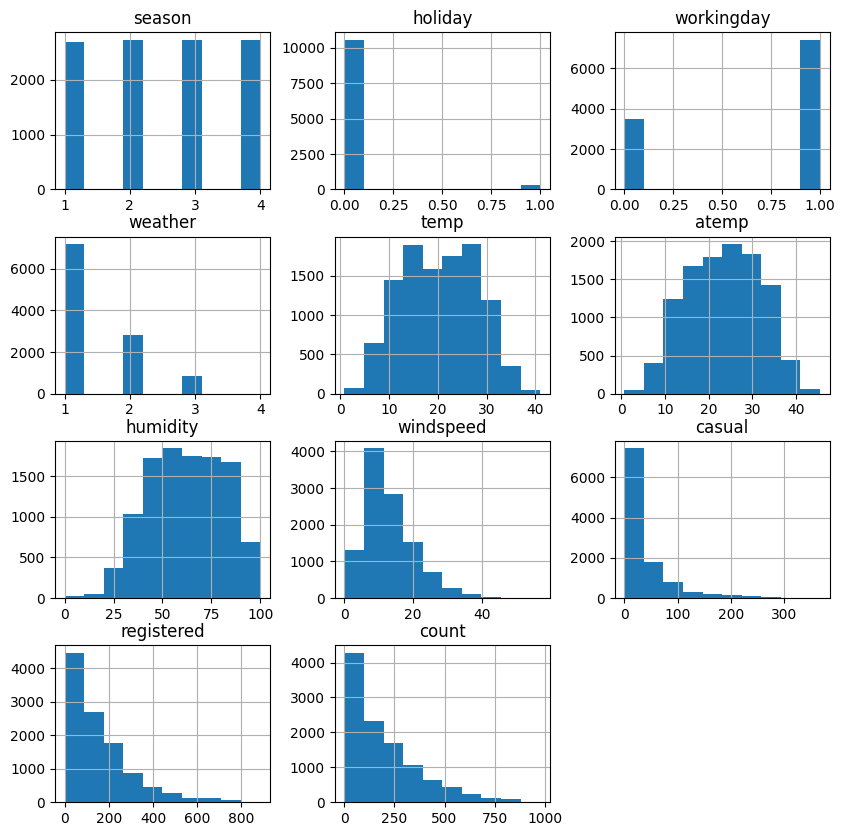

In [ ]:
df.hist(figsize=(10,10))
plt.show()

In [ ]:
df.season.value_counts()

season
4    2734
2    2733
3    2733
1    2686
Name: count, dtype: int64

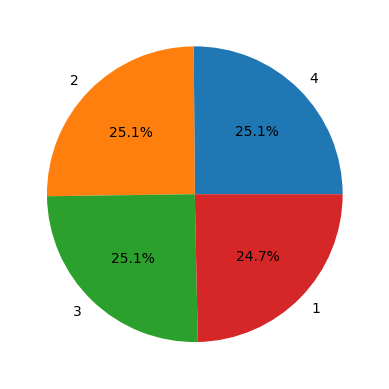

In [ ]:
plt.pie(df['season'].value_counts(),labels=df['season'].value_counts().index,autopct='%1.1f%%')
plt.show()

In [ ]:
df['weather'].value_counts()

weather
1    7192
2    2834
3     859
4       1
Name: count, dtype: int64

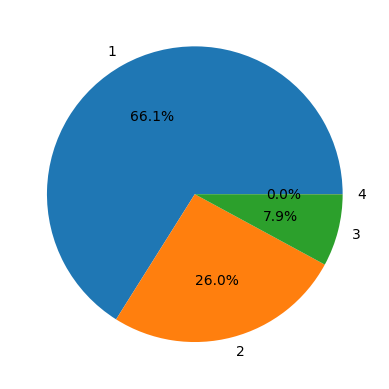

In [ ]:
plt.pie(df['weather'].value_counts(),labels=df['weather'].value_counts().index,autopct='%1.1f%%')
plt.show()

##e. Check for Outliers and deal with them accordingly.
Hint:
i. You can use Boxplot, Interquartile Range (IQR)
ii. Remove/Clip existing outliers as necessary.

In [ ]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [ ]:
df['temp'].mean()

20.23085981995223

In [ ]:
df['atemp'].mean()

23.655084052912

In [ ]:
df['humidity'].mean()

61.88645967297446

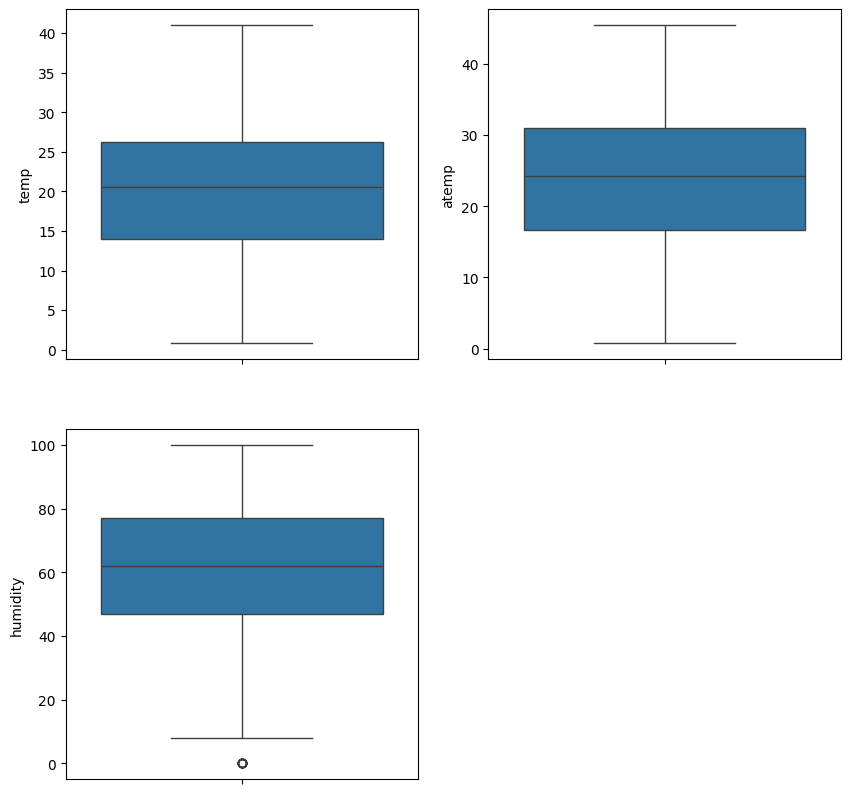

In [ ]:
plt.figure(figsize=(10,10))
plt.subplot(2,2,1)
sns.boxplot(df['temp'])
plt.subplot(2,2,2)
sns.boxplot(df['atemp'])
plt.subplot(2,2,3)
sns.boxplot(df['humidity'])

plt.show()
# df.boxplot(column='temp',by='weather',figsize=(8,8))
# plt.show()

In [ ]:
#removing/clipping outliers present in humidity dataset
q1=df['humidity'].quantile(0.25)
q3=df['humidity'].quantile(0.75)
iqr=q3-q1
lower_limit=q1-(1.5*iqr)
upper_limit=q3+(1.5*iqr)
# for i in df['humidity']:
#     if i>upper_limit or i<lower_limit:
#         df['humidity']=df['humidity'].replace(i,np.nan,inplace=True)
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


#2. Try establishing a Relationship between the Dependent and Independent Variables.

Hint:
i. Plot a Correlation Heatmap and draw insights.
ii. Remove the highly correlated variables, if any.

In [ ]:
df['season']=df['season'].astype('category')
df['holiday']=df['holiday'].astype('category')
df['workingday']=df['workingday'].astype('category')
df['weather']=df['weather'].astype('category')

In [ ]:
df.dtypes

datetime        object
season        category
holiday       category
workingday    category
weather       category
temp           float64
atemp          float64
humidity         int64
windspeed      float64
casual           int64
registered       int64
count            int64
dtype: object

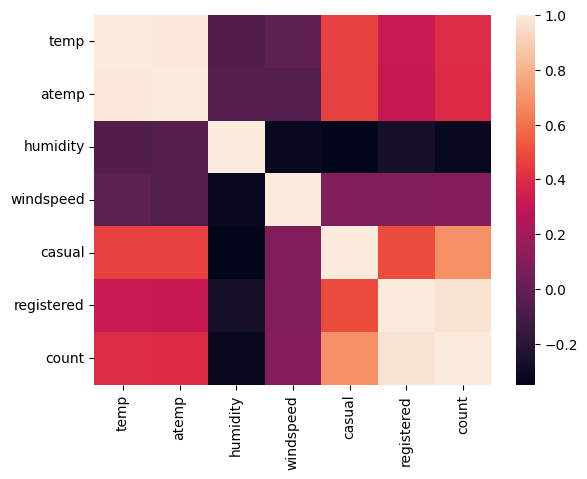

In [ ]:
numerical_columns = df.select_dtypes(include='number')
sns.heatmap(numerical_columns.corr())
plt.show()

#3. Check if there any significant difference between the no. of bike rides on Weekdays and Weekends?

In [ ]:
ndf=df.copy()


In [ ]:
# ndf.tail()

In [ ]:
#groupby datetime
ndf['datetime']=pd.to_datetime(ndf['datetime'])
ndf['date']=ndf['datetime'].dt.date
# ndf.groupby('date')
# ndf.head()

In [ ]:
#drop datetime column
ndf.drop('datetime',axis=1,inplace=True)

In [ ]:
numerical_cols = ndf.select_dtypes(include=['number']).columns.tolist()

In [ ]:
ndf_datewise = ndf.groupby('date').agg(
    {**{col: 'sum' for col in numerical_cols},
     **{col: 'first' for col in ndf.columns if col not in numerical_cols and col != 'datetime'}}
)#.reset_index()

In [ ]:
ndf_datewise.drop('date',axis=1,inplace=True)

In [ ]:
ndf_datewise['weekend'] = np.where((ndf_datewise['workingday'] == 0) & (ndf_datewise['holiday'] == 0), 1, 0)

In [ ]:
ndf_datewise.head()

,temp,atemp,humidity,windspeed,casual,registered,count,season,holiday,workingday,weather,weekend
date,,,,,,,,,,,,
2011-01-01,338.66,436.350,1934,257.9969,331,654,985,1,0,0,1,1
2011-01-02,342.76,406.800,1601,382.9988,131,670,801,1,0,0,2,1
2011-01-03,177.12,208.345,962,366.0076,120,1229,1349,1,0,1,1,0
2011-01-04,188.60,243.940,1358,247.0156,108,1454,1562,1,0,1,1,0
2011-01-05,214.02,263.660,1005,288.0129,82,1518,1600,1,0,1,1,0


In [ ]:
#convert categorical values to int
ndf_datewise['weekend']=ndf_datewise['weekend'].astype('int')

In [ ]:
a=ndf_datewise.groupby('weekend')['count'].mean()
weekend_mean=a[1]
b=ndf_datewise.groupby('workingday')['count'].mean()
workday_mean=b[1]
print('weekend_mean=',weekend_mean,'workday_mean=',workday_mean)

weekend_mean= 4523.212121212121 workday_mean= 4600.012861736334


##a. Formulate Null Hypothesis (H0) and Alternate Hypothesis (H1)

case1)<br>
 Null Hypothesis (H0): there is no difference between the no. of rides on Weekdays and Weekends<br>
 Alternate Hypothesis (Ha): there is significant difference between the no. of rides on Weekdays and Weekends

 case2)<br>
  Null Hypothesis (H0): there is no difference between the no. of rides on Weekdays and Weekends<br>
  Alternate Hypothesis (Ha): no. of rides on weekend is less than no. of rides on weekdays

In [ ]:
#case1)

WE=ndf_datewise[ndf_datewise['weekend']==1]
WD=ndf_datewise[ndf_datewise['workingday']==1]
WD

,temp,atemp,humidity,windspeed,casual,registered,count,season,holiday,workingday,weather,weekend
date,,,,,,,,,,,,
2011-01-03,177.12,208.345,962,366.0076,120,1229,1349,1,0,1,1,0
2011-01-04,188.60,243.940,1358,247.0156,108,1454,1562,1,0,1,1,0
2011-01-05,214.02,263.660,1005,288.0129,82,1518,1600,1,0,1,1,0
2011-01-06,192.70,268.190,1192,138.0200,88,1518,1606,1,0,1,1,0
2011-01-07,185.32,240.165,1147,260.0069,148,1362,1510,1,0,1,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...
2012-12-13,291.10,353.025,1166,279.9997,425,5107,5532,4,0,1,2,0
2012-12-14,277.16,353.030,1543,211.0165,429,5182,5611,4,0,1,1,0
2012-12-17,387.04,481.800,2177,157.9994,212,4373,4585,4,0,1,2,0


In [ ]:
t_stat, pvalue = ttest_ind(WE['count'], WD['count'])
print('t_stat=',t_stat,'pvalue=',pvalue)

t_stat= -0.39575743552286574 pvalue= 0.692475366809191


In [ ]:
alpha = 0.05 # 95% confidence

if pvalue < alpha:
  print('Reject H0')
else:
  print ('Fail to Reject H0')

Fail to Reject H0


Hence, there is no difference between the rides on weekdays and weekends

#4. Check if the demand of bicycles on rent is the same for different Weather conditions?

##a. Formulate Null Hypothesis (H0) and Alternate Hypothesis (H1)

#Null hypo.(H0) = Demand of bicycles on rent is same for different Weather conditions
#Alternate hypo.(Ha) = Demand of bicycles on rent is not same for different Weather conditions

##b. Select an appropriate test - One-way ANOVA test

In [ ]:
ndf_datewise.head()

,temp,atemp,humidity,windspeed,casual,registered,count,season,holiday,workingday,weather,weekend
date,,,,,,,,,,,,
2011-01-01,338.66,436.350,1934,257.9969,331,654,985,1,0,0,1,1
2011-01-02,342.76,406.800,1601,382.9988,131,670,801,1,0,0,2,1
2011-01-03,177.12,208.345,962,366.0076,120,1229,1349,1,0,1,1,0
2011-01-04,188.60,243.940,1358,247.0156,108,1454,1562,1,0,1,1,0
2011-01-05,214.02,263.660,1005,288.0129,82,1518,1600,1,0,1,1,0


In [ ]:
ndf_datewise.groupby('weather')['count'].mean()

weather
1    4745.638158
2    4288.112903
3    3967.000000
4            NaN
Name: count, dtype: float64

In [ ]:
g1 = ndf_datewise[ndf_datewise["weather"]==1]["count"]
g2 = ndf_datewise[ndf_datewise["weather"]==2]["count"]
g3 = ndf_datewise[ndf_datewise["weather"]==3]["count"]

In [ ]:
print('g1_mean=',g1.mean(),'g2_mean=',g2.mean(),'g3_mean=',g3.mean())

g1_mean= 4745.638157894737 g2_mean= 4288.112903225807 g3_mean= 3967.0


In [ ]:
f_stats, p_value = f_oneway(g1, g2, g3)

print("test statistic:",f_stats)
print("p_value:",p_value)

test statistic: 4.27090894667042
p_value: 0.01453578545105127


In [ ]:
if p_value < 0.05:
    print("Reject H0")
    print("Demand of bicycles on rent is not same for different Weather conditions")
else:
    print("Fail to reject H0")
    print("Demand of bicycles on rent is same for different Weather conditions")

Reject H0
Demand of bicycles on rent is not same for different Weather conditions


##c. Check assumptions of the test


###i. Normality

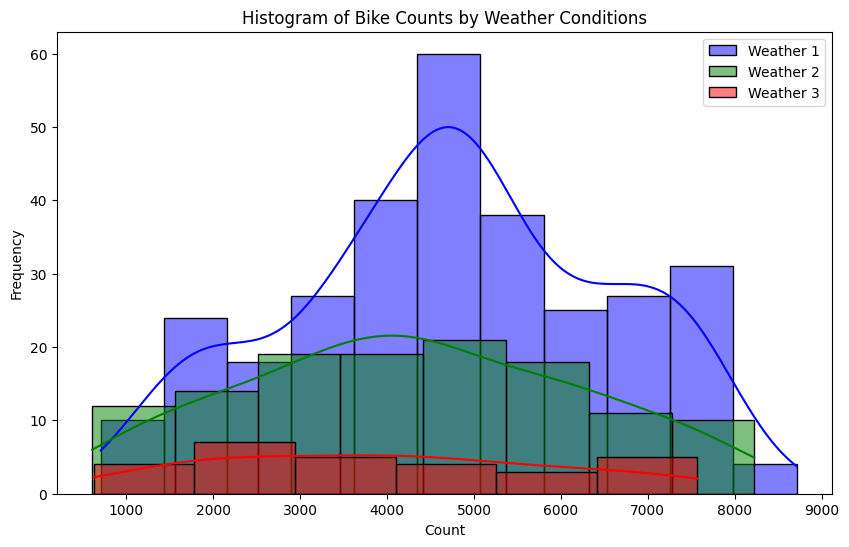

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(g1, color='blue', label='Weather 1', kde=True)
sns.histplot(g2, color='green', label='Weather 2', kde=True)
sns.histplot(g3, color='red', label='Weather 3', kde=True)

plt.xlabel('Count')
plt.ylabel('Frequency')
plt.title('Histogram of Bike Counts by Weather Conditions')
plt.legend()

plt.show()


###ii. Equality Variance-  Levene’s test

In [ ]:
# H0: Variances are equal
# Ha: Variances are not equal
levene_stat, p_value = levene(g1,g2,g3)
if p_value < 0.05:
    print("Variances are not equal")
else:
    print("Variances are equal")


Variances are equal


#5. Check if the demand of bicycles on rent is the same for different Seasons?

In [ ]:
ndf_datewise.head()

,temp,atemp,humidity,windspeed,casual,registered,count,season,holiday,workingday,weather,weekend
date,,,,,,,,,,,,
2011-01-01,338.66,436.350,1934,257.9969,331,654,985,1,0,0,1,1
2011-01-02,342.76,406.800,1601,382.9988,131,670,801,1,0,0,2,1
2011-01-03,177.12,208.345,962,366.0076,120,1229,1349,1,0,1,1,0
2011-01-04,188.60,243.940,1358,247.0156,108,1454,1562,1,0,1,1,0
2011-01-05,214.02,263.660,1005,288.0129,82,1518,1600,1,0,1,1,0


##a. Formulate Null Hypothesis (H0) and Alternate Hypothesis (H1)

In [ ]:
#Null hypo. (H0): demand of bicycles on rent is the same for different Seasons
#Alternate hypo. (Ha): demand of bicycles on rent is the not same for different Seasons

##b. Select an appropriate test - One-way ANOVA test

In [ ]:
ndf_datewise['season'].value_counts()

season
1    114
2    114
3    114
4    114
Name: count, dtype: int64

In [ ]:
ndf_datewise.groupby('season')['count'].mean()

season
1    2741.210526
2    5160.368421
3    5619.842105
4    4772.228070
Name: count, dtype: float64

In [ ]:
ag1 = ndf_datewise[ndf_datewise["season"]==1]["count"]
ag2 = ndf_datewise[ndf_datewise["season"]==2]["count"]
ag3 = ndf_datewise[ndf_datewise["season"]==3]["count"]
ag4 = ndf_datewise[ndf_datewise["season"]==4]["count"]

In [ ]:
print('ag1_mean=',ag1.mean(),'ag2_mean=',ag2.mean(),'ag3_mean=',ag3.mean())

ag1_mean= 2741.2105263157896 ag2_mean= 5160.368421052632 ag3_mean= 5619.8421052631575


In [ ]:
f_stats, p_value = f_oneway(ag1, ag2, ag3)

print("test statistic:",f_stats)
print("p_value:",p_value)

test statistic: 116.57291471182938
p_value: 2.961126757283756e-39


In [ ]:
if p_value < 0.05:
    print("Reject H0")
    print("Demand of bicycles on rent is the not same for different season")
else:
    print("Fail to reject H0")
    print("Demand of bicycles on rent is the same for different season")

Reject H0
Demand of bicycles on rent is the not same for different season


##c. Check assumptions of the test


###i. Normality

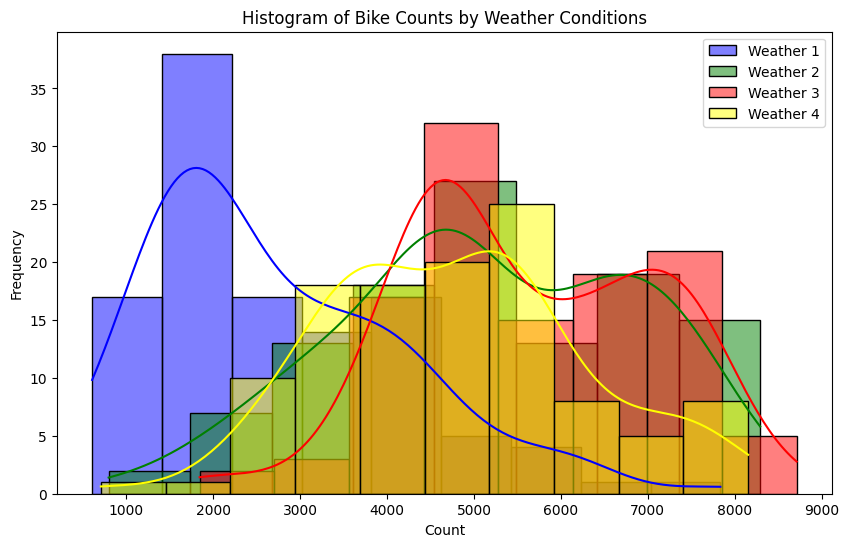

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(ag1, color='blue', label='Weather 1', kde=True)
sns.histplot(ag2, color='green', label='Weather 2', kde=True)
sns.histplot(ag3, color='red', label='Weather 3', kde=True)
sns.histplot(ag4, color='yellow', label='Weather 4', kde=True)

plt.xlabel('Count')
plt.ylabel('Frequency')
plt.title('Histogram of Bike Counts by Weather Conditions')
plt.legend()

plt.show()


###ii. Equality Variance-  Levene’s test

In [ ]:
# H0: Variances are equal
# Ha: Variances are not equal
levene_stat, p_value = levene(ag1,ag2,ag3,ag4)
if p_value < 0.05:
    print("Variances are not equal")
else:
    print("Variances are equal")


Variances are equal


#6. Check if the Weather conditions are significantly different during different Seasons?

In [ ]:
contingency_table = pd.crosstab(df['season'], df['weather'])
print(contingency_table)


weather     1    2    3  4
season                    
1        1759  715  211  1
2        1801  708  224  0
3        1930  604  199  0
4        1702  807  225  0


In [ ]:
# Perform Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Print the test results
print(f'Chi2 Statistic: {chi2}')
print(f'p-value: {p}')
print(f'Degrees of Freedom: {dof}')
print(f'Expected Frequencies: \n{expected}')


Chi2 Statistic: 49.158655596893624
p-value: 1.549925073686492e-07
Degrees of Freedom: 9
Expected Frequencies: 
[[1.77454639e+03 6.99258130e+02 2.11948742e+02 2.46738931e-01]
 [1.80559765e+03 7.11493845e+02 2.15657450e+02 2.51056403e-01]
 [1.80559765e+03 7.11493845e+02 2.15657450e+02 2.51056403e-01]
 [1.80625831e+03 7.11754180e+02 2.15736359e+02 2.51148264e-01]]


In [ ]:
# Significance level
alpha = 0.05

# Decision
if p <= alpha:
    print("Reject the null hypothesis: Weather conditions are not independent of the seasons.")
else:
    print("Fail to reject the null hypothesis: Weather conditions are independent of the seasons.")


Reject the null hypothesis: Weather conditions are not independent of the seasons.


#Insights:

1. temp, feeling temp and humidity has normal distribution
2. temp column has mean of 20
3. atemp column has mean of 24
4. humidity has mean of 62
5. from the heatmap we can tell that, humidity has negative correlation with windspeed, casual, registered and count
6. There is no difference between the rides on weekdays and weekends
7. Demand of bicycles on rent is same for different weather condition
8. Demand of bicycles on rent is the same for different season


#Recommendations:


1. Target Low Humidity Days:

Since humidity has a negative correlation with wind speed, casual, registered, and count, promoting bike rentals on days with lower humidity could potentially increase demand.

2. Optimize for Weekdays:

Although there is no difference in rides between weekdays and weekends, consider creating weekday-specific promotions or events to encourage more consistent usage throughout the week.

3. Seasonal Promotions:

Since the demand for bicycles on rent is the same across different seasons, develop seasonal promotions and marketing strategies to maintain a steady rental rate all year round. Highlight the unique aspects of each season that make biking enjoyable.

4. Temperature Considerations:

With mean temperatures of 20°C and apparent temperatures of 24°C, ensure that bikes are well-maintained and comfortable to ride in these conditions. Offering bikes with features that enhance comfort in varying temperatures can be appealing.

5. Marketing and Community Engagement:

Increase awareness through targeted marketing campaigns. Engage with local communities and cycling groups to build a loyal customer base. Hosting cycling events and participating in local activities can also boost visibility.

